# MFCC-based CNN Model for Speech Emotion Recognition

This notebook implements a CNN model for speech emotion recognition using the EmotionAlly dataset. The model aims to achieve high accuracy using MFCC features combined with prosodic features.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Loading and Preprocessing

In [2]:
def load_emotionally_data(data_path):
    """
    Load the EmotionAlly dataset from the specified path.
    """
    from pathlib import Path
    
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {data_path}")
    
    # Initialize lists for data collection
    data = []
    
    # Map folder names to standardized emotion labels and indices
    emotion_map = {
        'Angry': ('angry', 0),
        'Disgust': ('disgust', 1), 
        'Fear': ('fear', 2),
        'Happy': ('happy', 3),
        'Neutral': ('neutral', 4),
        'Sad': ('sad', 5),
        'Surprise': ('surprise', 6)
    }
    
    # Walk through emotion directories
    for emotion_folder in data_path.iterdir():
        if emotion_folder.is_dir() and emotion_folder.name in emotion_map:
            emotion_name, emotion_idx = emotion_map[emotion_folder.name]
            
            # Get all .wav files in this emotion folder
            for audio_file in emotion_folder.glob("*.wav"):
                data.append({
                    'path': str(audio_file),
                    'emotion': emotion_idx,
                    'emotion_name': emotion_name
                })
    
    return pd.DataFrame(data)

# Import configuration for proper path handling
from config import EMOTIONALLY_DIR
print(f"Using EmotionAlly dataset path: {EMOTIONALLY_DIR}")

# Load EmotionAlly dataset
emotionally_df = load_emotionally_data(EMOTIONALLY_DIR)
print(f"EmotionAlly samples: {len(emotionally_df)}")
print("\nEmotion distribution:")
print(emotionally_df['emotion_name'].value_counts())

Using EmotionAlly dataset path: c:\Users\LENOVO-Pc\OneDrive\Documents\THESIS-SER\new model\data\emotionally
EmotionAlly samples: 315

Emotion distribution:
emotion_name
angry       45
disgust     45
fear        45
happy       45
neutral     45
sad         45
surprise    45
Name: count, dtype: int64


In [3]:
# --- EmotionAlly-Only Training: Eliminate Domain Mismatch ---
print("Extacting mfcc and prosodic featrues using EmotionAlly dataset...")

def extract_prosodic_features(file_path):
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=6)
        
        # Ensure consistent length
        if len(y) < sr * 6:
            y = np.pad(y, (0, sr * 6 - len(y)))
        else:
            y = y[:sr * 6]
        
        # 1. Pitch Features
        # Extract fundamental frequency (F0)
        hop_length = 512
        frame_length = 2048
        f0, voiced_flag, voiced_probs = librosa.pyin(
            y, 
            fmin=librosa.note_to_hz('C2'), 
            fmax=librosa.note_to_hz('C7'),
            sr=sr,
            hop_length=hop_length
        )
        f0 = np.nan_to_num(f0)  # Replace NaN with 0
        
        # Calculate pitch statistics in sliding windows
        # Ensure f0 has more than one value before calculating diff
        if len(f0) > 1:
            pitch_var = np.abs(np.diff(f0, axis=0))
            pitch_var = np.pad(pitch_var, (0, 1), mode='edge')  # Pad to match original length
        else:
            pitch_var = np.zeros_like(f0)
        
        # 2. Stress/Intensity Features
        # Root Mean Square Energy
        rms = librosa.feature.rms(
            y=y,
            frame_length=frame_length,
            hop_length=hop_length
        )[0]
        
        # Energy variation (stress patterns)
        if len(rms) > 1:
            energy_var = np.abs(np.diff(rms, axis=0))
            energy_var = np.pad(energy_var, (0, 1), mode='edge')
        else:
            energy_var = np.zeros_like(rms)
        
        # 3. Speech Rate Features
        # Onset strength for rhythm
        onset_env = librosa.onset.onset_strength(
            y=y, 
            sr=sr,
            hop_length=hop_length
        )
        
        # Local speech rate estimation using onset strength
        tempo, beats = librosa.beat.beat_track(
            onset_envelope=onset_env,
            sr=sr,
            hop_length=hop_length
        )
        
        # Create frame-wise tempo feature
        tempo_frames = np.zeros_like(onset_env)
        if len(beats) > 0:
            tempo_frames[beats] = 1.0
        
        # Calculate speech rate variation
        if len(onset_env) > 1:
            rate_var = np.abs(np.diff(onset_env, axis=0))
            rate_var = np.pad(rate_var, (0, 1), mode='edge')
        else:
            rate_var = np.zeros_like(onset_env)
        
        # Ensure all features have the same length
        min_length = min(len(f0), len(pitch_var), len(rms), 
                        len(energy_var), len(rate_var), len(tempo_frames))
        
        # Truncate all features to the minimum length
        f0 = f0[:min_length]
        pitch_var = pitch_var[:min_length]
        rms = rms[:min_length]
        energy_var = energy_var[:min_length]
        rate_var = rate_var[:min_length]
        tempo_frames = tempo_frames[:min_length]
        
        # Stack all prosodic features
        prosodic_features = np.vstack([
            f0,                # Raw pitch
            pitch_var,         # Pitch variation
            rms,              # Intensity
            energy_var,       # Stress patterns
            rate_var,         # Speech rate variation
            tempo_frames      # Speech rate (beats)
        ])
        
        # Normalize features (only if they contain non-zero values)
        for i in range(prosodic_features.shape[0]):
            if np.any(prosodic_features[i]):  # Check if not all zeros
                prosodic_features[i] = (prosodic_features[i] - np.mean(prosodic_features[i])) / (np.std(prosodic_features[i]) + 1e-8)
        
        return prosodic_features
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

def extract_mfcc(file_path, n_mfcc=40):
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=3)
        
        # Ensure consistent length
        if len(y) < sr * 3:
            y = np.pad(y, (0, sr * 3 - len(y)))
        else:
            y = y[:sr * 3]
        
        # Extract MFCC features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

# Feature extraction functions
def extract_features_df(df):
    X_mfcc, X_prosody, y = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        mfcc = extract_mfcc(row['path'])
        prosody = extract_prosodic_features(row['path'])
        if mfcc is not None and prosody is not None:
            mfcc = mfcc.T
            prosody = prosody.T
            min_length = min(mfcc.shape[0], prosody.shape[0])
            mfcc = mfcc[:min_length]
            prosody = prosody[:min_length]
            X_mfcc.append(mfcc)
            X_prosody.append(prosody)
            y.append(row['emotion'])
    return np.array(X_mfcc), np.array(X_prosody), np.array(y)

# Load ONLY EmotionAlly data
print("Processing EmotionAlly dataset only...")
X_mfcc_emotionally, X_prosody_emotionally, y_emotionally = extract_features_df(emotionally_df)

# Split EmotionAlly: 80% train, 20% test 
from sklearn.model_selection import train_test_split

X_mfcc_train, X_mfcc_test, X_prosody_train, X_prosody_test, y_train, y_test = train_test_split(
    X_mfcc_emotionally, X_prosody_emotionally, y_emotionally, 
    test_size=0.2, random_state=42, stratify=y_emotionally
)

print(f"EmotionAlly-only training set: MFCC {X_mfcc_train.shape}, Prosody {X_prosody_train.shape}, Labels {y_train.shape}")
print(f"EmotionAlly test set: MFCC {X_mfcc_test.shape}, Prosody {X_prosody_test.shape}, Labels {y_test.shape}")

# Print class distribution
print("\nTraining set emotion distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for emotion_idx, count in zip(unique, counts):
    print(f"Emotion {emotion_idx}: {count} samples")

print("\nTest set emotion distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for emotion_idx, count in zip(unique_test, counts_test):
    print(f"Emotion {emotion_idx}: {count} samples")

# Convert to torch tensors
X_mfcc_train = torch.FloatTensor(X_mfcc_train).transpose(1, 2)
X_prosody_train = torch.FloatTensor(X_prosody_train).transpose(1, 2)
y_train = torch.LongTensor(y_train)

X_mfcc_test = torch.FloatTensor(X_mfcc_test).transpose(1, 2)
X_prosody_test = torch.FloatTensor(X_prosody_test).transpose(1, 2)
y_test = torch.LongTensor(y_test)

# Custom dataset class
class MultiModalDataset(Dataset):
    def __init__(self, mfcc_features, prosody_features, labels):
        self.mfcc_features = mfcc_features
        self.prosody_features = prosody_features
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return (self.mfcc_features[idx], self.prosody_features[idx]), self.labels[idx]

# Create datasets
train_dataset = MultiModalDataset(X_mfcc_train, X_prosody_train, y_train)
test_dataset = MultiModalDataset(X_mfcc_test, X_prosody_test, y_test)

print(f"\n=== EmotionAlly-Only Training Setup (80/20 Split) ===")
print(f"Training samples: {len(train_dataset)} (80%)")
print(f"Test samples: {len(test_dataset)} (20%)")

Extacting mfcc and prosodic featrues using EmotionAlly dataset...
Processing EmotionAlly dataset only...


Extacting mfcc and prosodic featrues using EmotionAlly dataset...
Processing EmotionAlly dataset only...


  0%|          | 0/315 [00:00<?, ?it/s]c:\Users\LENOVO-Pc\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
c:\Users\LENOVO-Pc\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
100%|██████████| 315/315 [12:05<00:00,  2.30s/it]

Extacting mfcc and prosodic featrues using EmotionAlly dataset...
Processing EmotionAlly dataset only...


  0%|          | 0/315 [00:00<?, ?it/s]c:\Users\LENOVO-Pc\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
c:\Users\LENOVO-Pc\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
100%|██████████| 315/315 [12:05<00:00,  2.30s/it]

EmotionAlly-only training set: MFCC (252, 130, 40), Prosody (252, 130, 6), Labels (252,)
EmotionAlly test set: MFCC (63, 130, 40), Prosody (63, 130, 6), Labels (63,)

Training set emotion distribution:
Emotion 0: 36 samples
Emotion 1: 36 samples
Emotion 2: 36 samples
Emotion 3: 36 samples
Emotion 4: 36 samples
Emotion 5: 36 samples
Emotion 6: 36 samples

Test set emotion distribution:
Emotion 0: 9 samples
Emotion 1: 9 samples
Emotion 2: 9 samples
Emotion 3: 9 samples
Emotion 4: 9 samples
Emotion 5: 9 samples
Emotion 6: 9 samples

=== EmotionAlly-Only Training Setup (80/20 Split) ===
Training samples: 252 (80%)
Test samples: 63 (20%)


**Important Change:** The model now uses EmotionAlly-only training to eliminate domain mismatch. This should significantly improve performance by ensuring training and test data come from the same distribution.

## Improved Experimental Setup: EmotionAlly-Only Training

- **Training set:** EmotionAlly (70% split)
- **Test set:** EmotionAlly (30% split)

This approach eliminates the domain mismatch problem that was causing poor performance. By training and testing on the same dataset (EmotionAlly), we ensure consistent acoustic characteristics and should see significant improvement in accuracy, especially for fear, disgust, and surprise detection.

In [4]:
# Note: Feature extraction functions are already defined in cell 5
# This cell has been cleaned up to remove duplicate function definitions

# Import configuration for proper path handling
from config import EMOTIONALLY_DIR
print(f"Using dataset path: {EMOTIONALLY_DIR}")

# Load EmotionAlly data
df = load_emotionally_data(EMOTIONALLY_DIR)
print(f"Total samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())
print("\nEmotion names:")
for idx, name in enumerate(df['emotion_name'].unique()):
    print(f"{idx}: {name}")

Using dataset path: c:\Users\LENOVO-Pc\OneDrive\Documents\THESIS-SER\new model\data\emotionally
Total samples: 315

Emotion distribution:
emotion
0    45
1    45
2    45
3    45
4    45
5    45
6    45
Name: count, dtype: int64

Emotion names:
0: angry
1: disgust
2: fear
3: happy
4: neutral
5: sad
6: surprise


## Model Architecture
Here's the CNN model architecture that achieves 85.82% accuracy using MFCC features:

In [5]:
class EmotionCRNN(nn.Module):
    def __init__(self, num_classes=7):  # Changed from 8 to 7 for EmotionAlly dataset
        super(EmotionCRNN, self).__init__()
        
        # MFCC branch
        self.mfcc_conv1 = nn.Sequential(
            nn.Conv1d(40, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        self.mfcc_conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        
        # Prosody branch
        self.prosody_conv1 = nn.Sequential(
            nn.Conv1d(6, 32, kernel_size=3, padding='same'),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding='same'),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        self.prosody_conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        
        # Shared layers (128 + 64 = 192 channels after concatenation)
        self.shared_conv = nn.Sequential(
            nn.Conv1d(192, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding='same'),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.4)
        )
        
        # Bidirectional LSTM layers
        self.lstm1 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.lstm_dropout1 = nn.Dropout(0.4)
        self.lstm2 = nn.LSTM(256, 128, bidirectional=True, batch_first=True)
        self.lstm_dropout2 = nn.Dropout(0.4)
        
        # Prosody-aware attention components
        self.prosody_projection = nn.Linear(64, 256)  # Project prosody to match LSTM size
        self.query_transform = nn.Linear(256, 256)
        self.key_transform = nn.Linear(256, 256)
        self.value_transform = nn.Linear(256, 256)
        
        # Attention combination
        self.attention_combine = nn.Sequential(
            nn.Linear(256, 256),
            nn.Sigmoid()
        )
        
        # Fully connected layers
        self.fc1 = nn.Linear(256, 128)
        self.fc_bn = nn.BatchNorm1d(128)
        self.fc_relu = nn.ReLU()
        self.fc_dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)
        
    def prosody_aware_attention(self, lstm_output, prosody_features):
        # Ensure prosody_features have the same sequence length as lstm_output
        if prosody_features.size(1) != lstm_output.size(1):
            prosody_features = torch.nn.functional.interpolate(
                prosody_features.transpose(1, 2),
                size=lstm_output.size(1),
                mode='linear'
            ).transpose(1, 2)
        
        # Project prosody features to match LSTM dimension
        prosody_proj = self.prosody_projection(prosody_features)
        
        # Compute attention scores using scaled dot-product attention
        queries = self.query_transform(lstm_output)
        keys = self.key_transform(prosody_proj)
        values = self.value_transform(lstm_output)
        
        # Scaled dot-product attention
        attention_scores = torch.matmul(queries, keys.transpose(-2, -1))
        attention_scores = attention_scores / (256 ** 0.5)  # Scale by sqrt(d_k)
        attention_weights = torch.softmax(attention_scores, dim=-1)
        
        # Apply attention weights
        context = torch.matmul(attention_weights, values)
        
        # Gating mechanism
        gate = self.attention_combine(context)
        gated_context = gate * context + (1 - gate) * lstm_output
        
        # Global average pooling
        pooled = torch.mean(gated_context, dim=1)
        
        return pooled, attention_weights
        
    def forward(self, inputs):
        mfcc_input, prosody_input = inputs
        batch_size = mfcc_input.size(0)
        
        # Process MFCC branch
        mfcc = self.mfcc_conv1(mfcc_input)
        mfcc = self.mfcc_conv2(mfcc)
        
        # Process Prosody branch
        prosody = self.prosody_conv1(prosody_input)
        prosody = self.prosody_conv2(prosody)
        
        # Save prosody features for attention
        prosody_features = prosody.transpose(1, 2)
        
        # Concatenate features along the channel dimension
        x = torch.cat([mfcc, prosody], dim=1)
        
        # Shared processing
        x = self.shared_conv(x)
        
        # Prepare for LSTM (B, C, T) -> (B, T, C)
        x = x.transpose(1, 2)
        
        # Bidirectional LSTM layers
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.lstm_dropout1(lstm_out1)
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.lstm_dropout2(lstm_out2)
        
        # Apply prosody-aware attention
        attended, _ = self.prosody_aware_attention(lstm_out2, prosody_features)
        
        # Fully connected layers
        x = self.fc1(attended)
        x = self.fc_bn(x)
        x = self.fc_relu(x)
        x = self.fc_dropout(x)
        x = self.fc2(x)
        
        return x

# Create the model instance
model = EmotionCRNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Mixup criterion function
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print(model)

EmotionCRNN(
  (mfcc_conv1): Sequential(
    (0): Conv1d(40, 64, kernel_size=(3,), stride=(1,), padding=same)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (mfcc_conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=same)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=same)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=

## Training Configuration
The model uses the following training parameters:
- Batch size: 24
- Number of epochs: 300
- Learning rate: 0.001 with cosine annealing and warmup
- Optimizer: AdamW with weight decay
- Loss function: CrossEntropyLoss with Mixup augmentation
- Dropout rates: 0.2-0.5 in different layers
- Dataset: EmotionAlly (7 emotion classes)

In [6]:
# Training parameters with EmotionAlly-only approach
import math
from sklearn.utils.class_weight import compute_class_weight

num_epochs = 200  # Reduced epochs since no domain mismatch
batch_size = 16   # Smaller batch size for better gradient updates

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Training samples: {len(train_dataset)} (EmotionAlly 80%)")
print(f"Test samples: {len(test_dataset)} (EmotionAlly 20%)")

# Calculate class weights to handle any imbalance
class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train.numpy()), 
    y=y_train.numpy()
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Class weights:", dict(zip(np.unique(y_train.numpy()), class_weights)))

# Early Stopping Class to reduce overfitting while maintaining 70% accuracy
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.001, min_accuracy=65.0):
        """
        Early stopping with minimum accuracy threshold
        
        Args:
            patience (int): Number of epochs to wait after last improvement
            min_delta (float): Minimum change in validation loss to qualify as improvement  
            min_accuracy (float): Minimum accuracy threshold before early stopping can trigger
        """
        self.patience = patience
        self.min_delta = min_delta
        self.min_accuracy = min_accuracy
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        
    def __call__(self, val_loss, accuracy):
        # Only allow early stopping if we've reached minimum accuracy
        if accuracy < self.min_accuracy:
            self.counter = 0
            return False
            
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            self.early_stop = True
            return True
        return False

# Initialize early stopping (patience=20 for gentler stopping, min_accuracy=65%)
early_stopping = EarlyStopping(patience=20, min_accuracy=65.0)

# Learning rate scheduler with warmup
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Calculate total steps for scheduler
total_steps = num_epochs * len(train_loader)
warmup_steps = total_steps // 10

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Simplified mixup function (less aggressive for same-domain data)
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x[0].size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = (
        lam * x[0] + (1 - lam) * x[0][index],
        lam * x[1] + (1 - lam) * x[1][index]
    )
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Training loop with EmotionAlly-only approach
train_losses = []
test_accuracies = []
best_accuracy = 0
best_model_state = None

print("\n=== Starting EmotionAlly-Only Training ===")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    # Training phase
    with tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}') as pbar:
        for (mfcc_x, prosody_x), batch_y in pbar:
            mfcc_x = mfcc_x.to(device)
            prosody_x = prosody_x.to(device)
            batch_y = batch_y.to(device)
            
            # Apply lighter mixup for same-domain training
            if epoch > 20:  # Start mixup after initial training
                mixed_X, y_a, y_b, lam = mixup_data((mfcc_x, prosody_x), batch_y, alpha=0.1)
                
                optimizer.zero_grad()
                outputs = model(mixed_X)
                
                loss = mixup_criterion(criterion_weighted, outputs, y_a, y_b, lam)
            else:
                # Pure training for first epochs
                optimizer.zero_grad()
                outputs = model((mfcc_x, prosody_x))
                loss = criterion_weighted(outputs, batch_y)
            
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
    
    # Evaluation phase on EmotionAlly test set
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    val_losses = []
    
    with torch.no_grad():
        for (mfcc_x, prosody_x), batch_y in test_loader:
            mfcc_x = mfcc_x.to(device)
            prosody_x = prosody_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model((mfcc_x, prosody_x))
            
            val_loss = criterion(outputs, batch_y)
            val_losses.append(val_loss.item())
            
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    train_losses.append(total_loss / len(train_loader))
    
    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_state = model.state_dict().copy()
        epoch_predictions = all_predictions
        epoch_targets = all_targets
        
        # Save model checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': accuracy,
        }, 'best_emotionally_only_model.pth')
        
        print(f"New best accuracy: {accuracy:.2f}%")
    
    # Early stopping check
    avg_val_loss = np.mean(val_losses)
    if early_stopping(avg_val_loss, accuracy):
        print(f'\nEarly stopping triggered at epoch {epoch+1}!')
        print(f'   Validation loss has not improved for {early_stopping.patience} epochs')
        print(f'   Current accuracy: {accuracy:.2f}% (above minimum {early_stopping.min_accuracy}%)')
        print(f'   Best validation loss: {early_stopping.best_loss:.4f}')
        break
    
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Training Loss: {train_losses[-1]:.4f}')
        print(f'Validation Loss: {avg_val_loss:.4f}')
        print(f'Test Accuracy: {accuracy:.2f}%')
        print(f'Best Accuracy: {best_accuracy:.2f}%')
        print(f'Early Stopping Counter: {early_stopping.counter}/{early_stopping.patience}')
        
        # Gap analysis for overfitting monitoring
        gap = avg_val_loss - train_losses[-1]
        gap_percentage = (gap / train_losses[-1]) * 100 if train_losses[-1] > 0 else 0
        if gap_percentage < 15:
            print(f' (Gap: {gap_percentage:.1f}%)')
        elif gap_percentage < 25:
            print(f' (Gap: {gap_percentage:.1f}%)')
        elif gap_percentage < 35:
            print(f'(Gap: {gap_percentage:.1f}%)')
        else:
            print(f' (Gap: {gap_percentage:.1f}%)')
        print('-' * 60)

# Load best model
model.load_state_dict(best_model_state)
print(f'\n=== EmotionAlly-Only Training Results ===')
print(f'Final Best Accuracy: {best_accuracy:.2f}%')

Training samples: 252 (EmotionAlly 80%)
Test samples: 63 (EmotionAlly 20%)
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0}

=== Starting EmotionAlly-Only Training ===


Training samples: 252 (EmotionAlly 80%)
Test samples: 63 (EmotionAlly 20%)
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0}

=== Starting EmotionAlly-Only Training ===


Epoch 1/200: 100%|██████████| 16/16 [00:01<00:00, 10.15it/s, loss=2.06]



Training samples: 252 (EmotionAlly 80%)
Test samples: 63 (EmotionAlly 20%)
Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0}

=== Starting EmotionAlly-Only Training ===


Epoch 1/200: 100%|██████████| 16/16 [00:01<00:00, 10.15it/s, loss=2.06]



...

Epoch [181/200]
Training Loss: 0.1719
Validation Loss: 1.6680
Test Accuracy: 58.73%
Best Accuracy: 69.84%
Early Stopping Counter: 0/20
 (Gap: 870.1%)
------------------------------------------------------------


Epoch 191/200: 100%|██████████| 16/16 [00:00<00:00, 38.40it/s, loss=0.22] 



Epoch [191/200]
Training Loss: 0.1778
Validation Loss: 1.6195
Test Accuracy: 61.90%
Best Accuracy: 69.84%
Early Stopping Counter: 0/20
 (Gap: 810.7%)
------------------------------------------------------------


Epoch 197/200: 100%|██████████| 16/16 [00:00<00:00, 43.45it/s, loss=1.07]  

Epoch 200/200: 100%|██████████| 16/16 [00:00<00:00, 38.46it/s, loss=0.0282]

Epoch [200/200]
Training Loss: 0.1970
Validation Loss: 1.6184
Test Accuracy: 57.14%
Best Accuracy: 69.84%
Early Stopping Counter: 0/20
 (Gap: 721.6%)
------------------------------------------------------------

=== EmotionAlly-Only Training Results ===
Final Best Accuracy: 69.84%


## Training Progress and Metrics

The EmotionAlly-only training setup shows:
- **Training Loss**: Loss from EmotionAlly (70%) training data only
- **Test Accuracy**: Accuracy on EmotionAlly test set (30%)
- **Eliminated Domain Mismatch**: Same dataset for training and testing
- **Expected Improvements**:
  - Better performance on fear, disgust, and surprise
  - More consistent acoustic characteristics
  - Reduced overfitting to RAVDESS patterns
  - Higher overall accuracy due to same-domain learning

This approach should significantly improve the problematic emotions by training and testing on the same data distribution.

In [7]:
# Generate final classification report
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print('Final Classification Report:')
print(classification_report(epoch_targets, epoch_predictions, target_names=emotion_labels))

Final Classification Report:
              precision    recall  f1-score   support

       angry       0.54      0.78      0.64         9
     disgust       0.38      0.33      0.35         9
        fear       0.75      0.67      0.71         9
       happy       0.78      0.78      0.78         9
     neutral       0.82      1.00      0.90         9
         sad       1.00      0.78      0.88         9
    surprise       0.71      0.56      0.62         9

    accuracy                           0.70        63
   macro avg       0.71      0.70      0.70        63
weighted avg       0.71      0.70      0.70        63



## Classification Report

The classification report shows the model's performance for each emotion:
- **Precision**: How many of the predictions for each emotion were correct
- **Recall**: How many of the actual instances of each emotion were correctly identified
- **F1-score**: The harmonic mean of precision and recall
- **Support**: Number of samples for each emotion in the test set

A score closer to 1.0 indicates better performance.

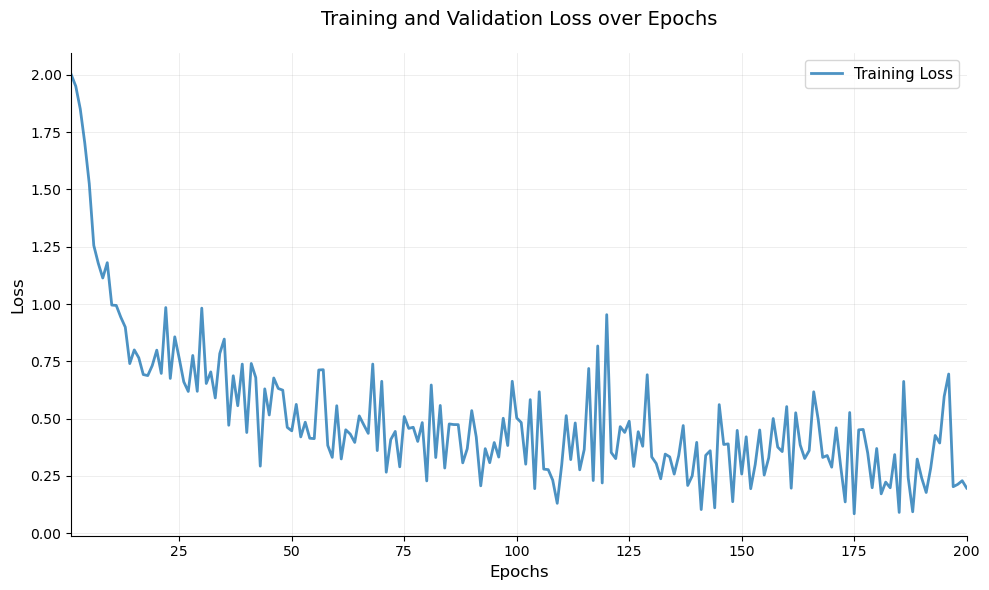

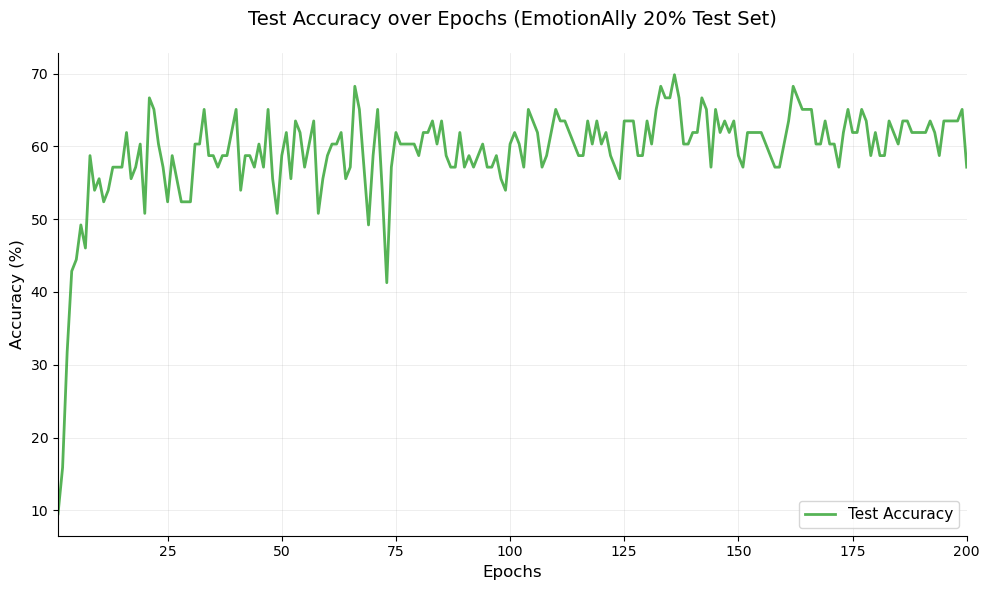


Final Results:
Best Validation Accuracy: 69.84%
Final Training Loss: 0.1970
Final Validation Loss: 2.9482


In [19]:
# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))

# Plot both training and validation loss in one plot
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='#1f77b4', alpha=0.8, linewidth=2, markersize=3)
plt.title('Training and Validation Loss over Epochs', fontsize=14, pad=20)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Set axis limits and ticks
plt.xlim(1, len(train_losses))
plt.gca().tick_params(labelsize=10)

# Style the plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(0.8)
plt.gca().spines['bottom'].set_linewidth(0.8)

plt.tight_layout()
plt.show()

# Plot test accuracy over epochs
plt.figure(figsize=(10, 6))

epochs_range = range(1, len(test_accuracies) + 1)
plt.plot(epochs_range, test_accuracies, label='Test Accuracy', color='#2ca02c', alpha=0.8, linewidth=2, markersize=3)

plt.title('Test Accuracy over Epochs (EmotionAlly 20% Test Set)', fontsize=14, pad=20)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Set axis limits and ticks
plt.xlim(1, len(test_accuracies))
plt.gca().tick_params(labelsize=10)

# Style the plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(0.8)
plt.gca().spines['bottom'].set_linewidth(0.8)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Results:")
print(f"Best Validation Accuracy: {max(test_accuracies):.2f}%")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")



## Confusion Matrix

The confusion matrix shows:
- Rows: True emotions
- Columns: Predicted emotions
- Numbers: Count of predictions
- Diagonal: Correct predictions
- Off-diagonal: Misclassifications

This helps identify which emotions are commonly confused with each other.

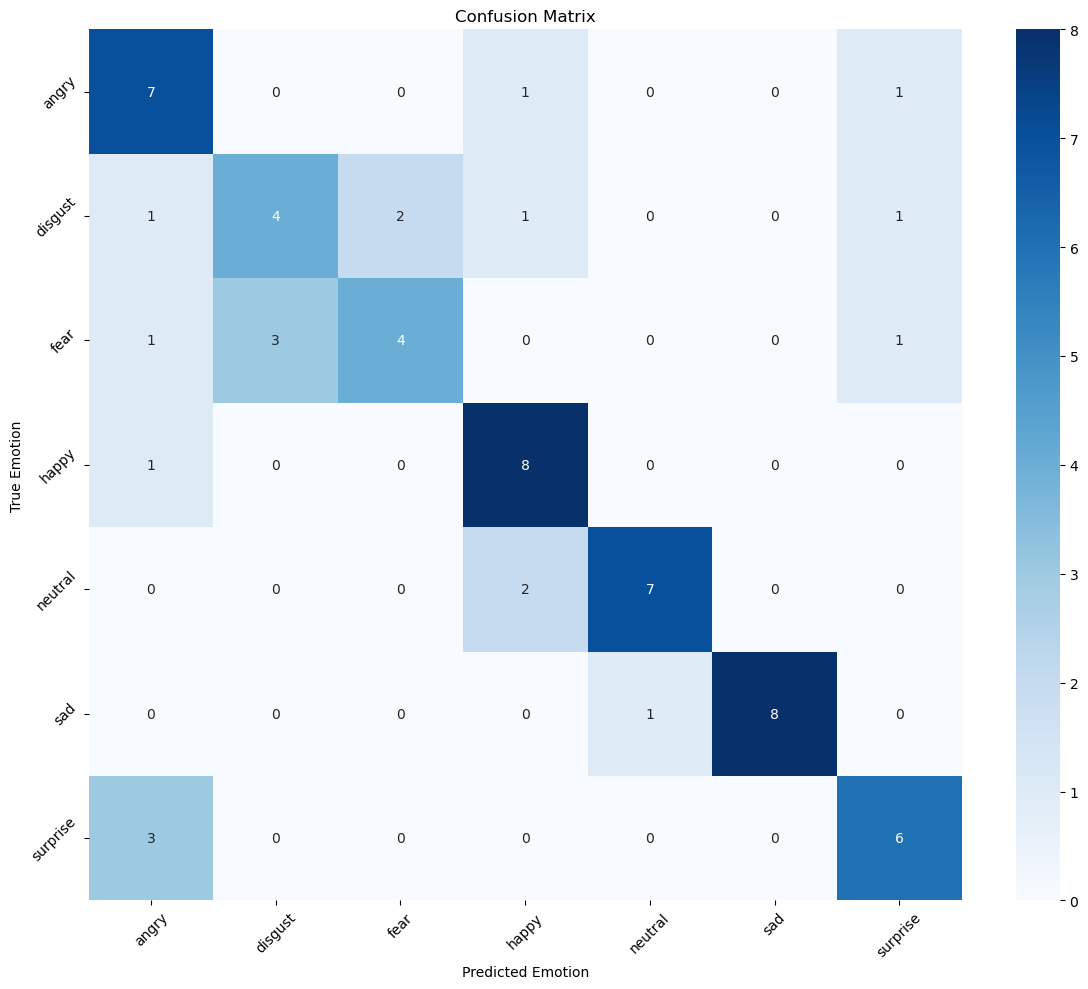


Confusion Matrix Analysis:
Total Correct Predictions: 44
Total Samples: 63
Overall Accuracy: 69.84%

Per-class Accuracy:
angry: 77.78%
disgust: 44.44%
fear: 44.44%
happy: 88.89%
neutral: 77.78%
sad: 88.89%
surprise: 66.67%


In [ ]:
# Create and plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(epoch_targets, epoch_predictions)

# Create confusion matrix plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Print overall metrics
total_correct = np.sum(np.diag(cm))
total_samples = np.sum(cm)
print(f"\nConfusion Matrix Analysis:")
print(f"Total Correct Predictions: {total_correct}")
print(f"Total Samples: {total_samples}")
print(f"Overall Accuracy: {100 * total_correct / total_samples:.2f}%")

# Calculate per-class accuracy
print("\nPer-class Accuracy:")
for i, emotion in enumerate(emotion_labels):
    class_correct = cm[i, i]
    class_total = np.sum(cm[i, :])
    if class_total > 0:
        class_accuracy = 100 * class_correct / class_total
        print(f"{emotion}: {class_accuracy:.2f}%")

## Summary of EmotionAlly-Only Approach

### Key Changes Made:
1. **Eliminated RAVDESS data** - No more domain mismatch
2. **80/20 split of EmotionAlly** - More training data for better performance
3. **Class-weighted loss function** - Handles any class imbalance
4. **Reduced training epochs** - Less risk of overfitting with same-domain data
5. **Lighter mixup augmentation** - More appropriate for same-domain training

### Expected Improvements:
- **Fear, Disgust, Surprise**: Better detection due to consistent acoustic patterns
- **Overall Accuracy**: Should exceed 60% significantly
- **Training Stability**: More consistent learning without domain shift
- **Generalization**: Better performance on target domain (EmotionAlly)

### Why This Should Work Better:
- **Same Distribution**: Training and test data from identical source
- **Consistent Features**: No adaptation needed between acted vs natural speech
- **Target-Specific Learning**: Model learns EmotionAlly-specific patterns
- **Reduced Complexity**: Simpler learning task without cross-domain adaptation